<a href="https://colab.research.google.com/github/NicholasBr7/Trabalho-Cocada-25.2/blob/main/Trabalho_Final_Cocada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aluno: Nicholas de Araujo Figueira**

# **DRE: 121088218**


O projeto final da disciplina de Computação Científica consiste em modelar computacionalmente o jogo "[Snakes and Ladders](https://en.wikipedia.org/wiki/Snakes_and_ladders)", o qual consiste em rolar dados e mover, conforme o número de casas indica. Caso o jogo pare em uma escada, o jogador é diretamente movido para o topo dela e caso caia na cabeça de uma cobra, ele é mandado para a cauda dela.

O objetivo central é tratar a dinâmica do tabuleiro como uma Cadeia de Markov de estados finitos, onde a movimentação é regida por uma Matriz de Probabilidade de Transição (Transition Probability Matrix - TPM) esparsa. A análise teórica se desdobra em três partes principais para compreender o comportamento do sistema.

1. utiliza-se sistemas lineares e a fatoração LU para calcular o tempo esperado de vitória a partir de qualquer casa, resolvendo a equação (I−Q)e=1.

2. Aplica-se a potenciação de matrizes e a análise espectral (autovalores) para estudar a distribuição de probabilidade de término em k rodadas e a velocidade de convergência do sistema para o estado final.

3. Implementa-se algoritmos de K-Means e PCA para classificar padrões de partidas simuladas, identificando perfis distintos de jogo baseados na sorte ou azar dos caminhos percorridos.

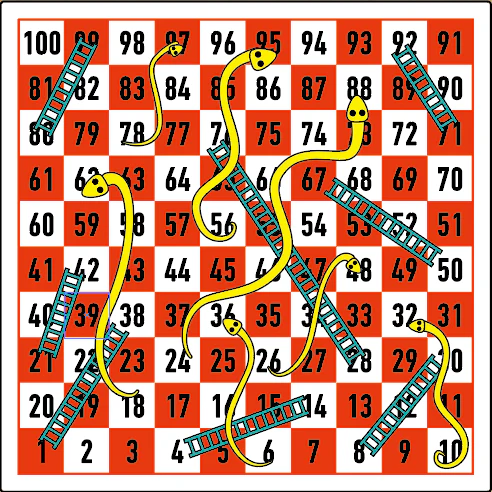


**Escadas**: (1-38), (4-14), (8-30), (21-42), (28-76), (50-67), (71-92), (80-99)

**Cobras**: (32-10), (36-6), (48-26), (62-18), (88-24), (95-56), (97-78)

In [ ]:
'''
Realiza-se a importação das funções necessárias e as regras estáticas do jogo.
Mapeaia-se as transições especiais em dicionários Python, conectando as casas
de origem às de destino para todas as Escadas (que avançam o jogador) e
Cobras (que o fazem recuar).
'''

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def criar_tabuleiro():
    """
    Regras e mapeamento de Cobras e Escadas.
    """
    escadas = {1: 38, 4: 14, 8: 30, 21: 42, 28: 76, 50: 67, 71: 92, 80: 99}
    cobras = {32: 10, 36: 6, 48: 26, 62: 18, 88: 24, 95: 56, 97: 78}

    # Une os dois dicionários em um só conjunto de 'saltos'
    saltos = {**escadas, **cobras}
    return 100, saltos

In [ ]:
'''
O código itera sobre cada casa, distribuindo uniformemente a probabilidade (1/6)
para os seis resultados possíveis do dado. A lógica verifica automaticamente
se o destino é uma cobra ou escada e redireciona o movimento, gerando a matriz
esparsa P que alimenta todos os cálculos subsequentes.
'''

def construir_matriz_transicao(n, saltos):
    """
    Gera a Matriz de Probabilidades de Transição (P) n x n.
    """
    P = np.zeros((n, n))

    # Itera sobre todas as casas exceto a última (que é final)
    for i in range(n - 1):
        for dado in range(1, 7):
            alvo = i + dado

            # Se passar de 100, para no 100
            if alvo >= n:
                dest_final = n - 1
            else:
                # Verifica se caiu em cobra ou escada.
                casa_tabuleiro = alvo + 1
                dest_casa = saltos.get(casa_tabuleiro, casa_tabuleiro)
                dest_final = dest_casa - 1

            # Adiciona probabilidade do dado
            P[i, dest_final] += 1/6

    # Estado Final (Absorvente): Uma vez na casa 100, probabilidade 1
    P[n-1, n-1] = 1.0
    return P

In [ ]:
'''
Função que resolve o problema do tempo médio de absorção. Isola-se a submatriz
Q (estados não finais) e resolvemos o sistema linear (I−Q)e=1. Utiliza-se a
Fatoração LU em vez da inversão direta de matrizes para garantir maior
eficiência computacional e estabilidade numérica na obtenção do vetor de médias.
'''

def calcular_tempo_esperado(P):
    """
    Resolve o sistema (I - Q)x = 1 para encontrar o tempo médio de absorção.
    """
    n = P.shape[0]
    # Q é a submatriz contendo apenas estados não finais
    Q = P[:-1, :-1]
    I = np.eye(n - 1)

    # Sistema Linear: A * x = b
    A = I - Q
    b = np.ones(n - 1)

    # Fatoração LU para resolução
    lu, piv = la.lu_factor(A)
    x = la.lu_solve((lu, piv), b)

    return x # Vetor com número esperado de jogadas a partir de cada casa

In [ ]:
'''
Extrai a submatriz Q da matriz P, calcula os autovalores de Q e os plota.
O segundo maior autovalor dita o comportamento da matriz.
'''

def analisar_espectro_autovalores(P):
    """
    Visualiza os autovalores da submatriz Q no plano complexo.
    O segundo maior autovalor global (lambda_dom de Q) dita a taxa de decaimento
    do jogo e a influência dos ciclos (cobras).
    """
    # Extrai submatriz Q (estados não finais)
    Q = P[:-1, :-1]

    autovalores = la.eigvals(Q)

    # Ordena por magnitude para identificar o lambda dominante
    autovalores_ord = sorted(autovalores, key=lambda x: np.abs(x), reverse=True)
    lambda_dom = np.abs(autovalores_ord[0]) # Atua como "fator de decaimento"

    plt.figure(figsize=(8, 8))

    # Círculo unitário (referência para estabilidade)
    circulo = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
    plt.gca().add_patch(circulo)

    # Plota autovalores
    plt.scatter(autovalores.real, autovalores.imag, marker='x', color='red', label='Autovalores de Q')

    # Destaca o Lambda com maior magnitude
    plt.scatter(autovalores_ord[0].real, autovalores_ord[0].imag, s=100,
                facecolors='none', edgecolors='blue', linewidth=2,
                label=f'Dominante |λ|={lambda_dom:.4f}')

    plt.title("Espectro de Autovalores da Matriz Q\n(Convergência do Sistema)")
    plt.xlabel("Parte Real")
    plt.ylabel("Parte Imaginária")
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

    return lambda_dom

In [ ]:
'''
Esta função gera dois gráficos: o gráfico de esparsidade, que revela a estrutura
matemática interna da matriz, e um mapa de calor do tabuleiro. O código converte
o vetor linear de tempos esperados em uma grade 10x10, permitindo visualizar
geograficamente a dificuldade de cada casa.
'''

def plotar_resumo_grafico(P, tempos_esperados):
    """
    Gera painel com:
    1. Estrutura de Esparsidade da Matriz (Spy Plot)[cite: 53].
    2. Mapa de Calor de Dificuldade (Heatmap) projetado no tabuleiro[cite: 71, 72].
    """
    plt.figure(figsize=(16, 7))

    # Gráfico 1: Estrutura da Matriz
    plt.subplot(1, 2, 1)
    plt.spy(P, markersize=1.5, color='red')
    plt.title("Visualização da Matriz Esparsa (P)", fontsize=12)
    plt.xlabel("Estado Destino")
    plt.ylabel("Estado Origem")

    # Gráfico 2: Mapa de Calor
    # Mapeia vetor linear 1D para grid 2D (10x10)
    valores_tabuleiro = np.zeros(100)
    valores_tabuleiro[:-1] = tempos_esperados

    grid = np.zeros((10, 10))
    for i in range(100):
        # Conversão de índice linear para coordenadas cartesianas do tabuleiro
        linha = 9 - (i // 10)
        coluna = i % 10
        grid[linha, coluna] = valores_tabuleiro[i]

    plt.subplot(1, 2, 2)
    # cmap='hot': Cores claras = Valores altos (Longe da vitória)
    sns.heatmap(grid, cmap="hot", annot=False, cbar_kws={'label': 'Jogadas Esperadas até Vencer'})
    plt.title("Mapa de Calor: Distância Temporal da Vitória)", fontsize=12)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Tempo médio esperado do início (Casa 0): 34.87 jogadas




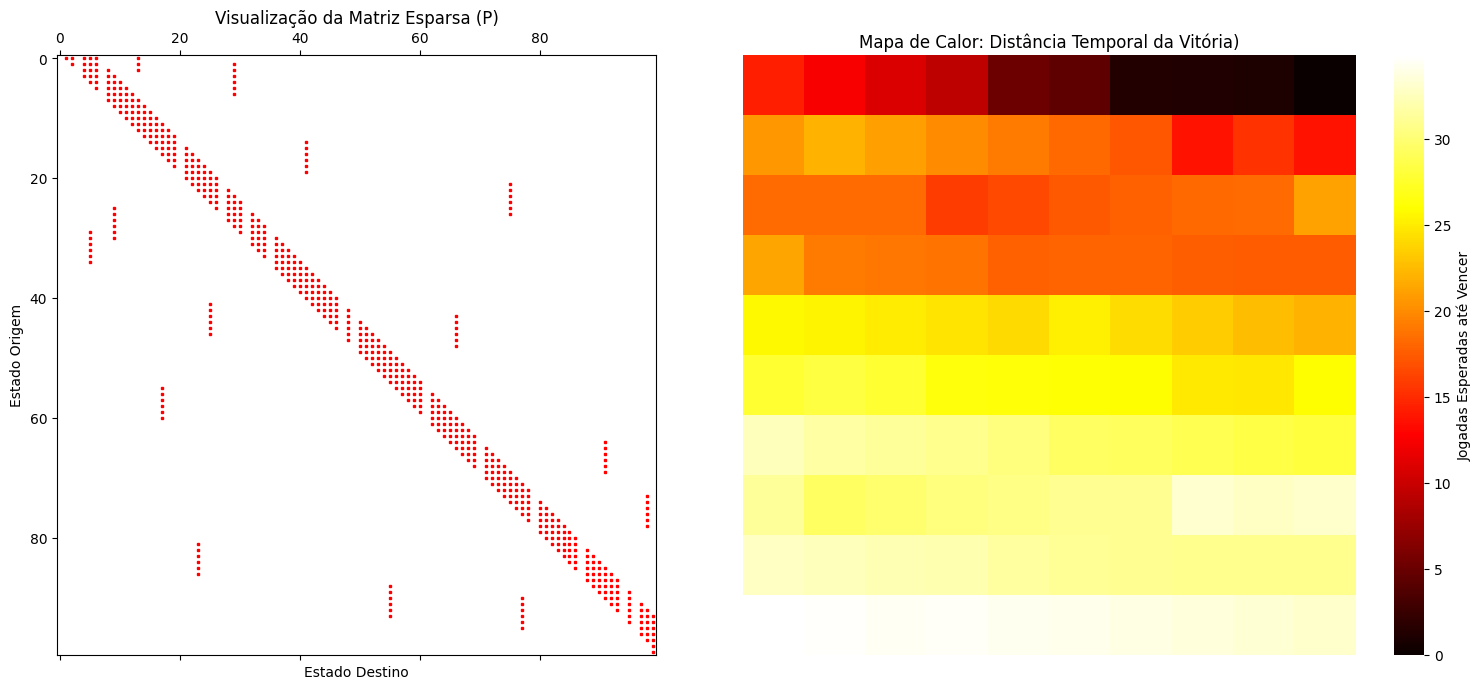

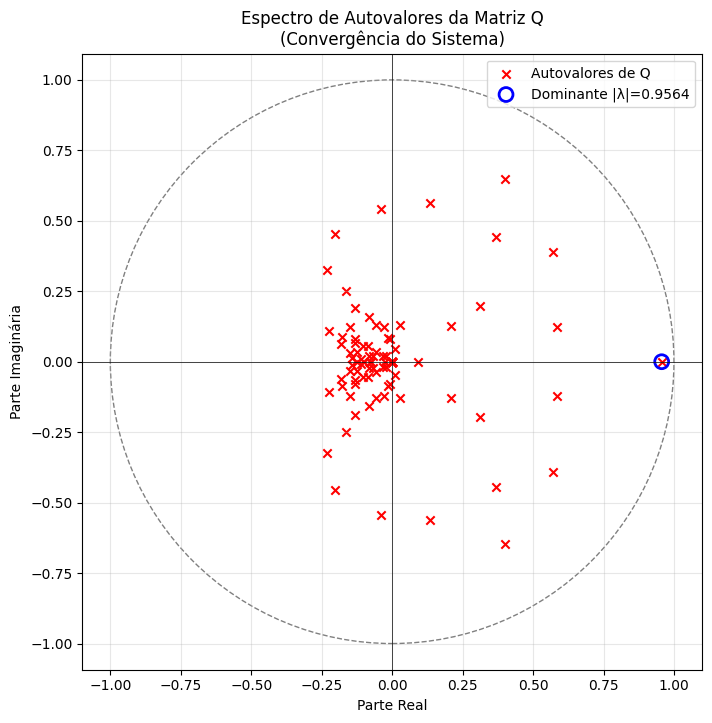

Autovalor Dominante (Q): |λ| = 0.9564

CONCLUSÕES ESPECTRAIS:
Taxa de decaimento: O valor 0.9564 indica que, assintoticamente,
cerca de 95.6% da probabilidade de o jogo continuar 'resta' a cada rodada
.


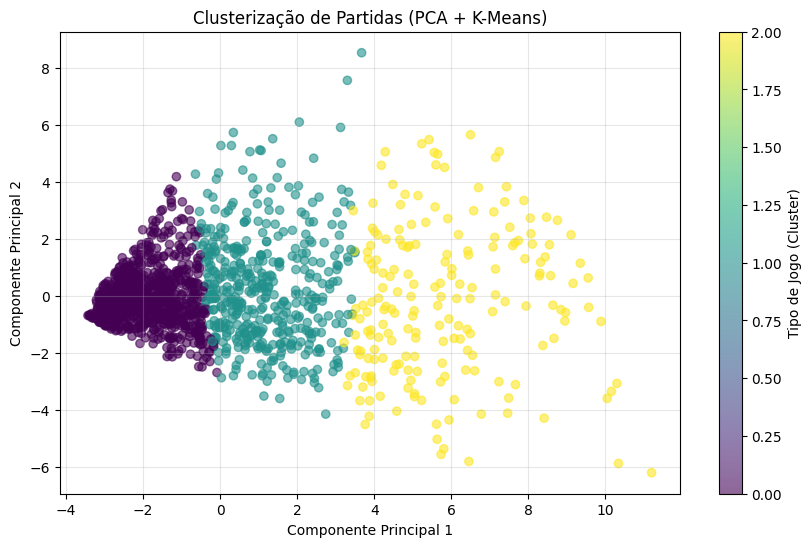

In [ ]:
'''
Esta função simula centenas de partidas para gerar dados comportamentais.
Utiliza-se o PCA para reduzir a dimensionalidade desses dados e o algoritmo
K-Means para agrupar as partidas em clusters. Isso permite identificar
estatisticamente os diferentes "tipos de jogos".
'''

def simular_partidas(P, n_jogos=1500, max_movimentos=100):
    """
    Simula partidas para gerar dados para o K-Means.
    Gera um 'Vetor de Ocupação': quantas vezes o jogador pisou em cada casa.
    """
    n_estados = P.shape[0]
    dados_partidas = []

    for _ in range(n_jogos):
        estado_atual = 0
        visitas = np.zeros(n_estados)
        movimentos = 0

        while estado_atual != n_estados - 1 and movimentos < max_movimentos:
            visitas[estado_atual] += 1
            # Sorteio do próximo estado usando as probabilidades da linha atual
            proximo_estado = np.random.choice(range(n_estados), p=P[estado_atual])
            estado_atual = proximo_estado
            movimentos += 1

        visitas[n_estados - 1] = 1 # Marca chegada
        dados_partidas.append(visitas)

    return np.array(dados_partidas)

def analisar_partidas(dados_partidas):
    # PCA (Redução de Dimensionalidade)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(dados_partidas)

    # K-Means (Clusterização)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(dados_partidas)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)

    plt.title("Clusterização de Partidas (PCA + K-Means)")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.colorbar(scatter, label='Tipo de Jogo (Cluster)')
    plt.grid(True, alpha=0.3)
    plt.show()

# Roda o código
n, saltos = criar_tabuleiro()
P = construir_matriz_transicao(n, saltos)
tempos = calcular_tempo_esperado(P)

print(f"Tempo médio esperado do início (Casa 0): {tempos[0]:.2f} jogadas\n\n")

plotar_resumo_grafico(P, tempos)

lambda_dom = analisar_espectro_autovalores(P)

print(f"Autovalor Dominante (Q): |λ| = {lambda_dom:.4f}")

print("\nCONCLUSÕES ESPECTRAIS:")
print(f"Taxa de decaimento: O valor {lambda_dom:.4f} indica que, assintoticamente,")
print(f"cerca de {lambda_dom*100:.1f}% da probabilidade de o jogo continuar 'resta' a cada rodada\n.")

dados_simulados = simular_partidas(P)
analisar_partidas(dados_simulados)